# 🪄 DSP Lab 2: Audio Magic, FFT & The Time-Frequency Rift

ยินดีต้อนรับสู่สัปดาห์ที่ 2 ของปฏิบัติการ DSP!
สัปดาห์ที่แล้วเราเป็น "ผู้สร้าง" (Synthesis) แต่สัปดาห์นี้เราจะรับบทเป็น "นักวิเคราะห์" (Analysis) เราจะมาเจาะลึกโครงสร้างของไฟล์เสียงจริง ถอดรหัสคลื่นที่ซับซ้อนให้กลายเป็นส่วนประกอบย่อยๆ และมองเห็นเสียงในรูปแบบของภาพ 2 มิติ

## 🎯 วัตถุประสงค์การเรียนรู้ (Mission Objectives)
1. สามารถโหลดและจัดการไฟล์เสียง `.wav` ในสภาพแวดล้อมของ Python ได้
2. เข้าใจและสามารถใช้งาน Fast Fourier Transform (FFT) เพื่อวิเคราะห์ความถี่ของสัญญาณ
3. **[New]** พิสูจน์การทำงานของ FFT ผ่านการวิเคราะห์ฮาร์มอนิกในระบบไฟฟ้า (Controlled Experiment)
4. **[Advanced]** เข้าใจปรากฏการณ์ Spectral Leakage และวิธีแก้ปัญหาด้วย Windowing Function
5. **[Advanced]** สามารถสร้าง Spectrogram เพื่อวิเคราะห์ความถี่ที่เปลี่ยนแปลงไปตามเวลา (Time-Frequency Analysis)
6. ทดลองดัดแปลงเสียง (Voice Disguise) ด้วยการเล่นกับ Sampling Rate

---
## 🚦 ลำดับขั้นตอนการทำภารกิจ (Mission Flow)

### Step 0: อัปโหลดข้อมูลเป้าหมาย (The Payload)
ก่อนเริ่มรันโค้ด คุณต้องมีไฟล์เสียงก่อน:
1. ใช้โทรศัพท์มือถือหรือคอมพิวเตอร์ อัดเสียงตัวเองพูดว่า *"Digital Signal Processing"* (ยาวประมาณ 2-3 วินาที)
2. แปลงไฟล์หรือเซฟให้เป็นนามสกุล `.wav` (หาเว็บแปลงไฟล์ mp3 to wav ในเน็ตได้เลย)
3. เปลี่ยนชื่อไฟล์เป็น `my_voice.wav`
4. อัปโหลดไฟล์นี้เข้าไปใน Google Colab (ลากไปวางที่แถบ Files รูปโฟลเดอร์ด้านซ้ายมือ)

---
### Step 1: เปิดประตูมิติ (Loading the Audio)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio

# MISSION 1: โหลดไฟล์เสียง my_voice.wav
# ฟังก์ชัน wavfile.read() จะคืนค่ามา 2 อย่างคือ Sampling Rate และ Array ข้อมูลเสียง
fs, data = wavfile.read('my_voice.wav')

# ถ้าเสียงที่อัดมาเป็น Stereo (2 Channels) เราจะรวบให้เป็น Mono (1 Channel) ด้วยการหาค่าเฉลี่ย
if len(data.shape) > 1:
    data = data.mean(axis=1)

print(f"Sampling Rate: {fs} Hz")
print(f"จำนวนจุดข้อมูลทั้งหมด: {len(data)} จุด")
print(f"ความยาวเสียง: {len(data)/fs:.2f} วินาที")

# ลองฟังเสียงต้นฉบับ
display(Audio(data, rate=fs))

Sampling Rate: 48000 Hz
จำนวนจุดข้อมูลทั้งหมด: 190464 จุด
ความยาวเสียง: 3.97 วินาที


---
### Step 1.5: บทพิสูจน์ทางวิศวกรรม (The Controlled Experiment)
ก่อนที่เราจะเอา FFT ไปใช้วิเคราะห์เสียงพูดที่ซับซ้อน เรามาทดสอบเครื่องมือนี้กับสิ่งที่เรา "ควบคุมได้" กันก่อน นั่นคือ **สัญญาณไฟฟ้า**

สมมติว่าไฟบ้านปกติมีความถี่ 50 Hz บริสุทธิ์ แต่อุปกรณ์อิเล็กทรอนิกส์ในโรงงานทำให้เกิดคลื่นแทรกซ้อน (Harmonics) คือ ฮาร์มอนิกที่ 3 (150 Hz) และฮาร์มอนิกที่ 5 (250 Hz) ปะปนเข้ามา

มาดูกันว่า FFT จะสามารถ "ถอดรหัส" สัญญาณที่ผสมกันยุ่งเหยิงนี้ ให้กลับมาเป็นตัวเลข 50, 150, และ 250 Hz ได้อย่างแม่นยำหรือไม่!

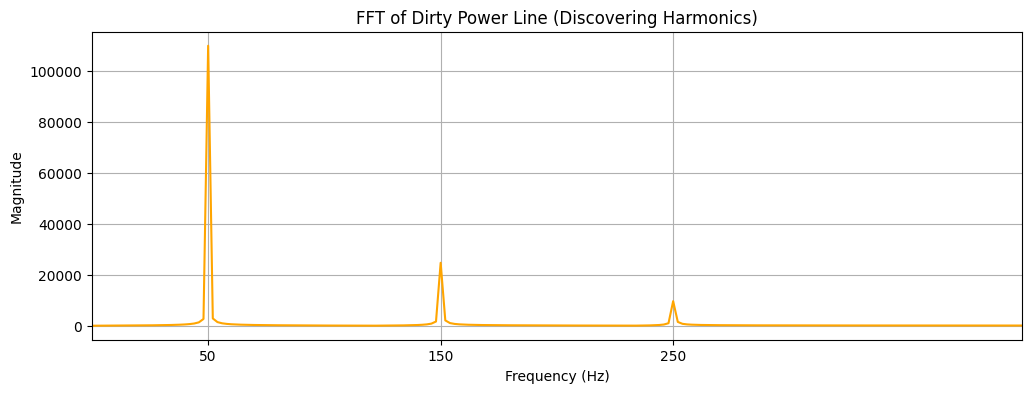

✅ พิสูจน์แล้ว! FFT สามารถแยกความถี่ที่ซ่อนอยู่ออกมาได้อย่างแม่นยำ พร้อมลุยกับเสียงพูดแล้ว!


In [3]:
# --- จำลองสัญญาณไฟบ้านที่ปนเปื้อน (The Dirty Power Line) ---
fs_power = 2000 # Sampling rate สำหรับสัญญาณไฟฟ้า
t_power = np.linspace(0, 0.5, int(fs_power * 0.5)) # ดูข้อมูลแค่ 0.5 วินาที

# 1. ไฟบ้านปกติ (Fundamental Frequency 50 Hz)
f0 = 50.0
y_fund = 220 * np.sin(2 * np.pi * f0 * t_power)

# 2. ฮาร์มอนิกรบกวน (Harmonic ที่ 3 และ 5)
y_h3 = 50 * np.sin(2 * np.pi * (3 * f0) * t_power) # 150 Hz
y_h5 = 20 * np.sin(2 * np.pi * (5 * f0) * t_power) # 250 Hz

# สัญญาณไฟบ้านที่ปนเปื้อน (ผสมรวมกัน)
y_dirty = y_fund + y_h3 + y_h5

# MISSION 1.5: ทำ FFT สัญญาณ y_dirty เพื่อพิสูจน์ว่ามีฮาร์มอนิกอะไรซ่อนอยู่บ้าง
# Hint: ใช้ np.fft.rfft() สำหรับข้อมูล และ np.fft.rfftfreq() สำหรับแกนความถี่
power_fft = np.abs(np.fft.rfft(y_dirty))
power_freqs = np.fft.rfftfreq(len(y_dirty), 1/fs_power)

# พล็อตกราฟผลลัพธ์จาก FFT
plt.figure(figsize=(12, 4))
plt.plot(power_freqs, power_fft, color='orange')
plt.title("FFT of Dirty Power Line (Discovering Harmonics)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 400) # ซูมดูความถี่ช่วง 0-400 Hz
plt.xticks([50, 150, 250]) # มาร์คจุดเป้าหมายให้เห็นชัดๆ
plt.grid(True)
plt.show()

print("✅ พิสูจน์แล้ว! FFT สามารถแยกความถี่ที่ซ่อนอยู่ออกมาได้อย่างแม่นยำ พร้อมลุยกับเสียงพูดแล้ว!")

---
### Step 2: แยกส่วนประกอบด้วยปริซึมคณิตศาสตร์ (The FFT Ritual)
คราวนี้เราจะใช้ Fast Fourier Transform (FFT) แบบเดียวกับที่ทำกับสัญญาณไฟฟ้า เพื่อดูว่าในเสียงพูดของเรา มีความถี่อะไรซ่อนอยู่บ้าง

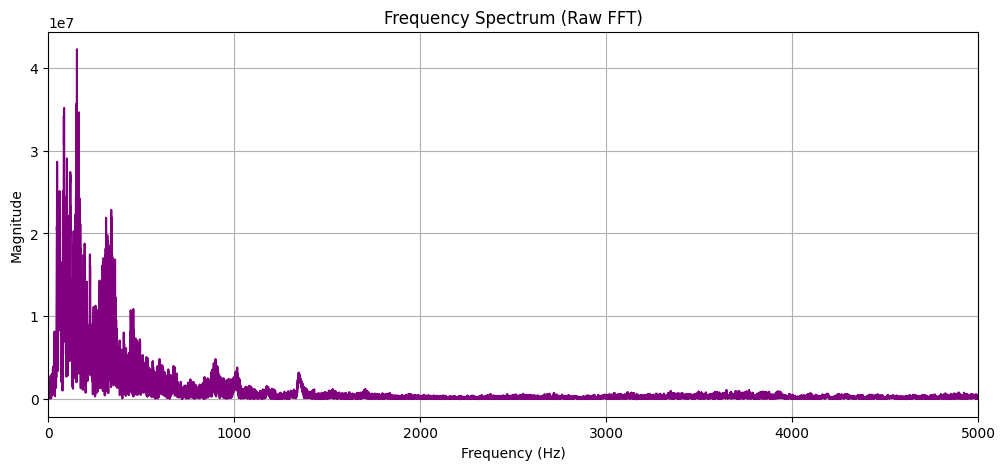

In [4]:
N = len(data) # จำนวนจุดข้อมูลทั้งหมดของไฟล์เสียงพูด

# MISSION 2.1: สร้างแกนความถี่ (X-axis) สำหรับพล็อตกราฟ
# MISSION 2.1: สร้างแกนความถี่ (X-axis) สำหรับพล็อตกราฟ
# Hint: ใช้คำสั่ง np.fft.rfftfreq(จำนวนจุดข้อมูล, 1/Sampling Rate)
frequencies = np.fft.rfftfreq(N, 1/fs)

# MISSION 2.2: ทำ FFT เพื่อแปลง Time Domain -> Frequency Domain
# Hint: ใช้คำสั่ง np.fft.rfft() กับตัวแปรข้อมูลเสียง
fft_values = np.fft.rfft(data)
# หาค่าขนาด (Magnitude) โดยใช้ค่าสัมบูรณ์ (Absolute value)
magnitude = np.abs(fft_values)

# พล็อตกราฟ Frequency Spectrum
plt.figure(figsize=(12, 5))
plt.plot(frequencies, magnitude, color='purple')
plt.title("Frequency Spectrum (Raw FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 5000) # ซูมดูแค่ช่วง 0 - 5000 Hz เพราะเสียงคนอยู่แถวๆ นี้
plt.grid(True)
plt.show()

---
### Step 3: อุดรอยรั่วของมิติ (Windowing & Spectral Leakage) [🔥 Advanced]
การทำ FFT ตรงๆ กับข้อมูลที่ถูกตัดมาแบบฉับพลัน จะทำให้เกิดสิ่งที่เรียกว่า "Spectral Leakage" (พลังงานความถี่รั่วไหลไปด้านข้าง ทำให้ยอดกราฟไม่แหลมคม) วิศวกร DSP แก้ปัญหานี้ด้วยการเอา "หน้าต่าง" (Windowing Function) มาครอบสัญญาณก่อนทำ FFT

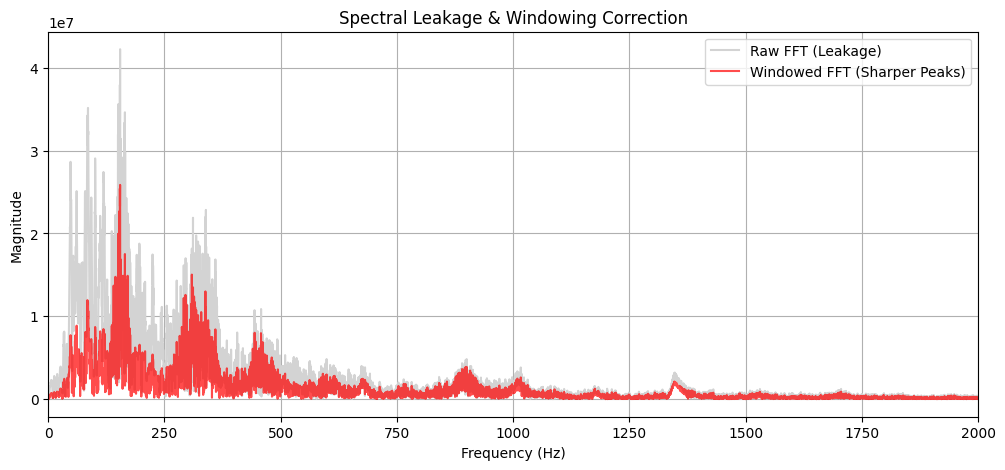

In [5]:
# MISSION 3: สร้าง Hanning Window ที่มีขนาดเท่ากับความยาวของข้อมูลเสียง (N)
# Hint: ใช้คำสั่ง np.hanning(ขนาด)
window = np.hanning(N)

# นำหน้าต่างไปคูณ (ครอบ) ข้อมูลเสียงต้นฉบับ
windowed_data = data * window

# ทำ FFT กับข้อมูลที่ครอบหน้าต่างแล้ว
windowed_fft = np.fft.rfft(windowed_data)
windowed_magnitude = np.abs(windowed_fft)

# พล็อตกราฟเปรียบเทียบ (ซูมดูช่วง 0-2000 Hz จะเห็นความต่างชัดเจน)
plt.figure(figsize=(12, 5))
plt.plot(frequencies, magnitude, color='lightgray', label='Raw FFT (Leakage)')
plt.plot(frequencies, windowed_magnitude, color='red', alpha=0.7, label='Windowed FFT (Sharper Peaks)')
plt.title("Spectral Leakage & Windowing Correction")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)
plt.legend()
plt.grid(True)
plt.show()

*💡 สังเกตดูว่าเส้นสีแดง (Windowed) จะมียอดแหลมที่ชัดเจนกว่า และฐานแคบกว่าเส้นสีเทา นั่นคือการระบุความถี่ที่แม่นยำขึ้น!*

---
### Step 4: เมื่อเสียงกลายเป็นภาพ 2 มิติ (The Spectrogram Matrix) [🔥 Advanced]
กราฟ FFT บอกเราได้ว่า "มีความถี่อะไรบ้าง" แต่บอกไม่ได้ว่า "ความถี่นั้นเกิดขึ้นตอนวินาทีที่เท่าไหร่" เราจึงต้องใช้ **Spectrogram**

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:8233: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


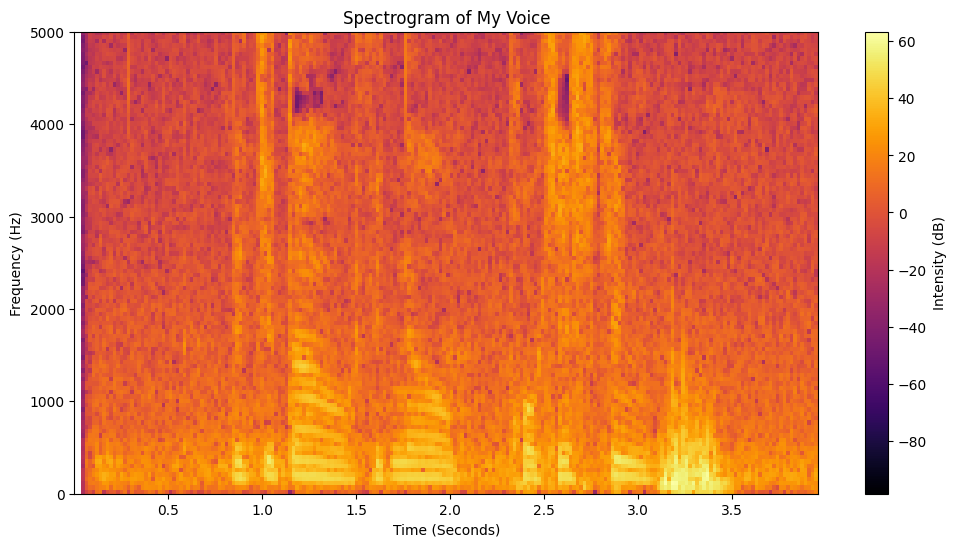

In [6]:
# MISSION 4: สร้าง Spectrogram (วิเคราะห์ความถี่เทียบกับเวลา)
plt.figure(figsize=(12, 6))

# ใช้คำสั่ง plt.specgram()
# โดยใส่พารามิเตอร์: ข้อมูลเสียง, NFFT=1024 (ขนาดหน้าต่างย่อย), Fs=fs (Sampling rate), และ cmap='inferno' (สีโทนร้อน)
plt.specgram(x=data, NFFT=1024, Fs=fs, cmap='inferno')

plt.title("Spectrogram of My Voice")
plt.xlabel("Time (Seconds)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 5000) # โฟกัสช่วงเสียงพูด
plt.colorbar(label='Intensity (dB)')
plt.show()

*💡 ลองวิเคราะห์ภาพที่ได้: สีสว่าง (เหลือง/ส้ม) หมายถึงพลังงานเสียงสูง ในช่วงเวลาที่คุณพูดคำว่า "Digital" มีแถบความถี่ไหนพุ่งขึ้นมาบ้าง?*

---
### Step 5: สายลับพรางเสียง (Voice Disguise)
กลับมาสู่เรื่องสนุกๆ เราสามารถเปลี่ยนโทนเสียงของเราได้ง่ายๆ ด้วยการโกง (Spoof) ตัวเลข Sampling Rate ในเครื่องเล่นเสียง!

In [7]:
print("1. เสียงดาร์ธเวเดอร์ (Darth Vader) - เล่นช้าลง ทุ้มลง")
# MISSION 5.1: ปรับ rate ให้ลดลงเหลือครึ่งหนึ่งของ fs ปกติ
display(Audio(data,rate=fs /2))

print("2. เสียงชิปมังก์ (Chipmunk) - เล่นเร็วขึ้น แหลมขึ้น")
# MISSION 5.2: ปรับ rate ให้เพิ่มขึ้นเป็น 1.5 เท่า หรือ 2 เท่าของ fs ปกติ
display(Audio(data, rate=fs *2))

1. เสียงดาร์ธเวเดอร์ (Darth Vader) - เล่นช้าลง ทุ้มลง


2. เสียงชิปมังก์ (Chipmunk) - เล่นเร็วขึ้น แหลมขึ้น


---
## 📥 การส่งมอบข้อมูล (Submission)
เมื่อรันกราฟ Spectrogram และพรางเสียงสำเร็จเรียบร้อยแล้ว:
1. กด `File` > `Save a copy in GitHub` เข้าสู่ Repository ของตนเอง
2. คัดลอกลิงก์ของไฟล์บน GitHub ไปส่งใน Google Form พร้อมทำ Self-Reflection
👉 **[อ้างอิง: SOP ขั้นตอนการส่งงาน DSP Lab]**

> *"The dimensions of time and frequency are now revealed. Analyze the pattern."*
> *- Living Incognito*